In [31]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
import os
from pydantic import BaseModel, Field
import operator

In [32]:
load_dotenv(override=True)

True

In [33]:
# Initialize Gemini Model
api_key = os.getenv('GEMINI_API_KEY') or os.getenv('GOOGLE_API_KEY')
model = ChatGoogleGenerativeAI(
    model='gemini-3.6-flash',
    google_api_key=api_key
)

In [34]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')

In [35]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description="the category of issue mentioned in the review")
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description="the emtional tone expressed by the user")
    urgency: Literal["low", "medium", "high"] = Field(description="How urgent or critical the issue appears to be")

In [36]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [37]:
# prompt = "What is the sentiment of the following review - the software too good"
# sentiment = structured_model.invoke(prompt)
# print(sentiment)

In [38]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [39]:
def find_sentiment(state: ReviewState):
    prompt = f'for the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return { 'sentiment': sentiment }

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return  'run_diagnosis'

def positive_response(state: ReviewState):
    prompt = f"""Write a warn thank-you message in response to this review:\n\n{state['review']}\\n
Also, kindly ask the user to leave feedback on our website
    """

    response = model.invoke(prompt).content

    return { 'response': response }


def run_diagnosis(state: ReviewState):
    prompt = f"""Diagnose this negative review: \n\n{state['review']}\\n
    return issue_type, tone and urgency
    """

    response = structured_model2.invoke(prompt)

    return {
        'diagnosis': response.model_dump() 
    }

def negative_response(state: ReviewState):
    diagnosis = state['diagnosis']
    prompt = f"""
    You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
    """

    response = model.invoke(prompt).content

    return {
        'response': response
    }

In [40]:
graph = StateGraph(ReviewState)

graph.add_node("find_sentiment", find_sentiment)
graph.add_node("positive_response", positive_response)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_response", negative_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

In [ ]:
initial_state={
    'review': "I've been using this app for about a month now, and I must say, the user interface is incredibly clean and intuitive. Everything is exactly where you'd expect it to be. It's rare to find something that just works without needing a tutorial.Great job to the design team!"
}

workflow.invoke(initial_state)

{'review': 'the product was really bad',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Other',
  'tone': 'disappointed',
  'urgency': 'low'},
 'response': [{'type': 'text',
   'text': "**Subject:** We’re here to help – Following up on your request\n\nHi [User Name],\n\nThank you for reaching out to us. I am truly sorry to hear that your recent experience didn't meet your expectations. I completely understand how disappointing it can be when things don't go as smoothly as they should, and I really appreciate you taking the time to share your feedback with us.\n\nI have thoroughly reviewed the details of your request regarding [insert brief summary of issue, e.g., your account inquiry / your recent experience]. Here is what I’ve done to resolve this for you:\n\n* **[Resolution Step 1]:** [e.g., Updated your settings / Applied a credit / Fixed the issue on our end]\n* **[Resolution Step 2 / Next Step]:** [e.g., You should now be able to access... / No further action is needed on

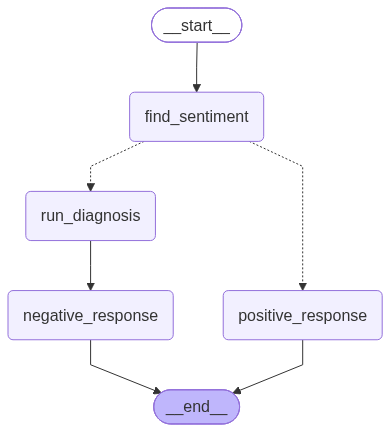

In [42]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())